# ERM demo notebook: synthetic models, teacher–student, theory, and MNIST-style random features

This notebook is a **progressive demo** of the refactored ERM toolbox:

- `data_models.py` — *how to generate data* (feature models → multi-class models → teacher/student → pruning / super-labels → MNIST-grouped).
- `losses_regularizers.py` — *what ERM objective you solve* (losses, regularizers, proximal maps, MC helpers).
- `erm_theory.py` — *how to solve ERM empirically* (SciPy optimizer) and a **Monte-Carlo fixed-point** solver for theoretical predictions.

The goal is to show:
1. how to build different data models quickly,
2. how those models feed a generic ERM solver,
3. how to run small parameter sweeps (regularization, class weights, mean separation, teacher alignment),
4. a MNIST-style demo with **8×8 downsampling** + **random features**.

> **Runtime note**: all experiments are set to small `p` and small sample sizes to keep execution fast.


In [20]:
import sys
import pathlib
import numpy as np
import matplotlib.pyplot as plt

# Make sure local modules are importable (notebook should live next to the .py files).
ROOT = pathlib.Path().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# --- Import project code ---
import data_models as dm
import losses_regularizers as lr

import erm_theory as et

rng = np.random.default_rng(0)


print("Loaded:")
print(" - data_models:", dm.__file__)
print(" - losses_regularizers:", lr.__file__)
print(" - erm_theory:", et.__file__)


Loaded:
 - data_models: /workspaces/Empirical-risk-minimization-asymptotics/data_models.py
 - losses_regularizers: /workspaces/Empirical-risk-minimization-asymptotics/losses_regularizers.py
 - erm_theory: /workspaces/Empirical-risk-minimization-asymptotics/erm_theory.py


## 1. Architecture in one picture

**Layer 1 — one-class feature models (`BaseFeatureModel`):** produce features `X` only, and expose their moments `(μ, C)`.

Examples:
- `GaussianModel`
- `UnifModel` (iid or affine to match a target covariance)
- `BetaModel` and `BernoulliModel` (can moment-match a requested mean/covariance, using an affine step when needed)
- `MultimodalModel` (mixture of feature models)

**Layer 2 — supervised multi-class (`MultiClassModel`):** a mixture of feature models where `y` *is the class label*.

**Layer 3 — teacher/student (`TeacherStudentModel`):** wraps an **x-model** and produces labels with a teacher mechanism (`linear_regression`, `sign`, `logistic`).

> Important: the **classes** of a teacher/student model are inherited from the underlying **x-model** (not from the label mechanism).

Finally, we also have:
- pruning / super-label models `u=(eps,y)` and `EpsScaledLoss`,
- `MNISTGroupedDataModel` for grouped digits + random feature maps.


## 2. One-class feature models (X-only) + moment matching

We'll generate a few distributions and check (visually + numerically) that the target mean/covariance is respected.

We use **histograms** because they are the quickest way to sanity-check a model.


BetaModel(iid) target mu: [0.2  0.5  0.75 0.35]
BetaModel(iid) emp    mu: [0.201 0.501 0.75  0.353]
BetaModel(iid) target var: [0.02 0.04 0.03 0.02]
BetaModel(iid) emp    var: [0.021 0.04  0.03  0.019]


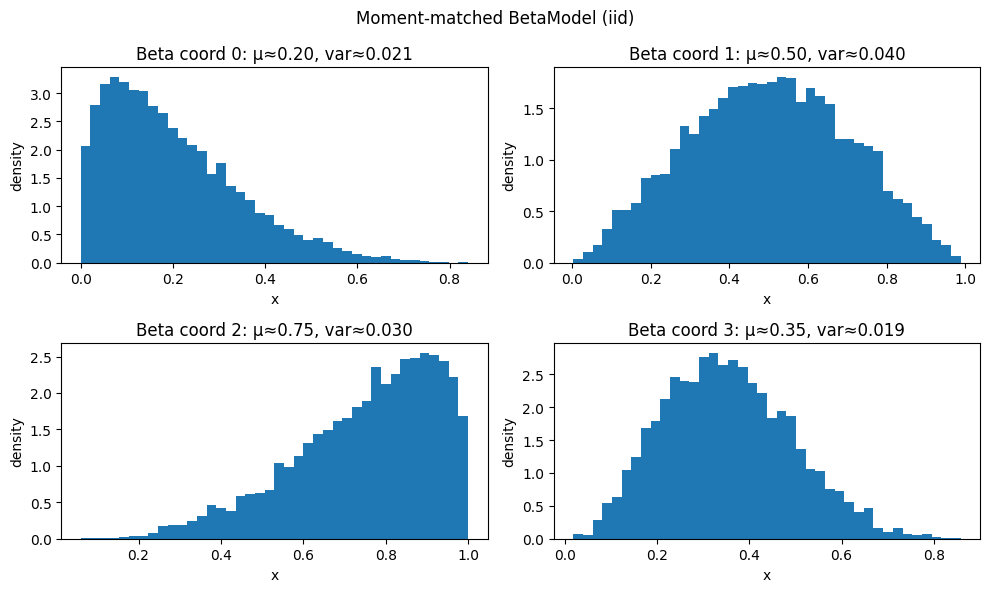


BernoulliModel(pm1,iid) target mu: [-0.5  0.   0.4  0.8]
BernoulliModel(pm1,iid) emp    mu: [-0.505  0.007  0.399  0.795]
BernoulliModel(pm1,iid) target var: [0.3  0.2  0.25 0.1 ]
BernoulliModel(pm1,iid) emp    var: [0.295 0.2   0.251 0.108]


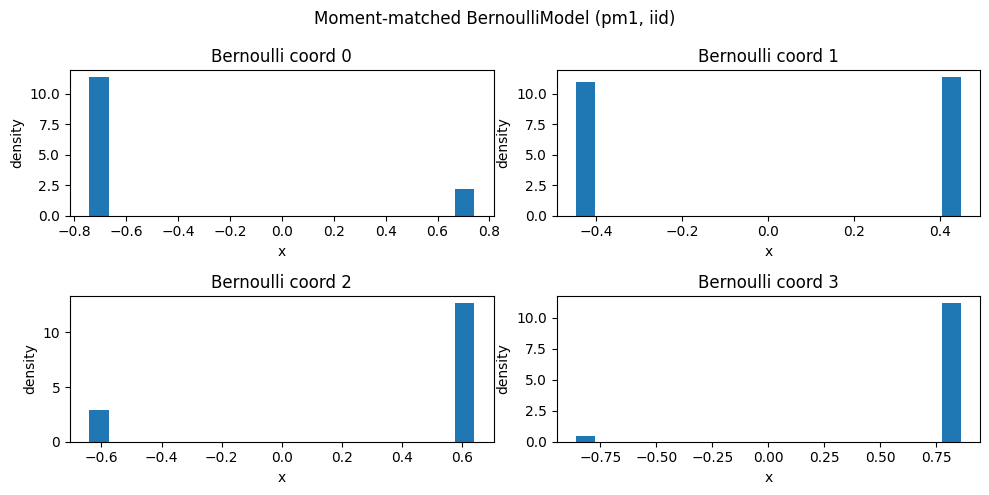

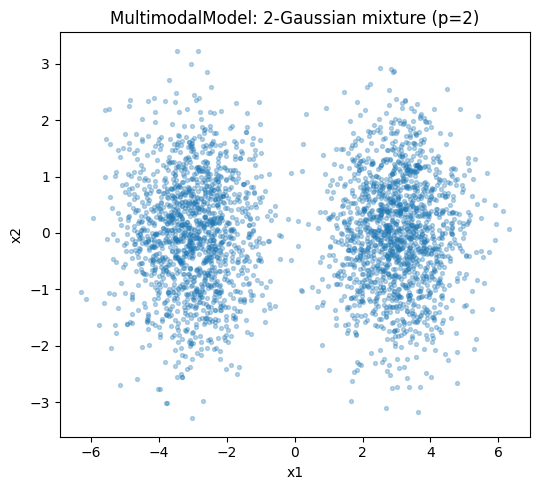

In [2]:
# --- BetaModel: moment-matched iid Beta coordinates ---
p = 4
mu_t = np.array([0.20, 0.50, 0.75, 0.35])
var_t = np.array([0.02, 0.04, 0.03, 0.02])
C_t = np.diag(var_t)

beta_iid = dm.BetaModel(p=p, mu=mu_t, C=C_t, mode="iid")
Xb = beta_iid.sample(6000, rng=rng)

emp_mu = Xb.mean(axis=0)
emp_var = Xb.var(axis=0)

print("BetaModel(iid) target mu:", mu_t)
print("BetaModel(iid) emp    mu:", np.round(emp_mu, 3))
print("BetaModel(iid) target var:", var_t)
print("BetaModel(iid) emp    var:", np.round(emp_var, 3))

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()
for j, ax in enumerate(axes):
    ax.hist(Xb[:, j], bins=40, density=True)
    ax.set_title(f"Beta coord {j}: μ≈{emp_mu[j]:.2f}, var≈{emp_var[j]:.3f}")
    ax.set_xlabel("x")
    ax.set_ylabel("density")
fig.suptitle("Moment-matched BetaModel (iid)")
plt.tight_layout()
plt.show()


# --- BernoulliModel: moment-matched two-point marginals ---
mu_t = np.array([-0.5, 0.0, 0.4, 0.8])
var_t = np.array([0.30, 0.20, 0.25, 0.10])
C_t = np.diag(var_t)

bern = dm.BernoulliModel(p=p, mu=mu_t, C=C_t, mode="iid", support="pm1")
Xr = bern.sample(6000, rng=rng)

emp_mu = Xr.mean(axis=0)
emp_var = Xr.var(axis=0)

print("\nBernoulliModel(pm1,iid) target mu:", mu_t)
print("BernoulliModel(pm1,iid) emp    mu:", np.round(emp_mu, 3))
print("BernoulliModel(pm1,iid) target var:", var_t)
print("BernoulliModel(pm1,iid) emp    var:", np.round(emp_var, 3))

fig, axes = plt.subplots(2, 2, figsize=(10, 5))
axes = axes.ravel()
for j, ax in enumerate(axes):
    ax.hist(Xr[:, j], bins=20, density=True)
    ax.set_title(f"Bernoulli coord {j}")
    ax.set_xlabel("x")
    ax.set_ylabel("density")
fig.suptitle("Moment-matched BernoulliModel (pm1, iid)")
plt.tight_layout()
plt.show()


# --- MultimodalModel: mixture of feature models ---
p2 = 2
C = np.eye(p2)
g1 = dm.GaussianModel(p=p2, mu=np.array([-3.0, 0.0]), C=C)
g2 = dm.GaussianModel(p=p2, mu=np.array([+3.0, 0.0]), C=C)

mix = dm.MultimodalModel(components=[g1, g2], weights=np.array([0.5, 0.5]))
Xm = mix.sample(3000, rng=rng)

fig, ax = plt.subplots(1, 1, figsize=(5.5, 5))
ax.scatter(Xm[:, 0], Xm[:, 1], s=8, alpha=0.3)
ax.set_title("MultimodalModel: 2-Gaussian mixture (p=2)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
plt.tight_layout()
plt.show()


## 3. MultiClassModel (y = class label): a simple binary Gaussian classification task

We build a two-class Gaussian mixture with labels `y ∈ {−1,+1}` and solve a regularized logistic regression ERM.

Then we sweep:
- **mean separation** (how well-separated the classes are),
- **class imbalance** (how skewed the mixture weights are).

We'll plot **classification error** (0–1 loss).


In [ ]:
def make_two_class_gaussian(p, delta, gamma_pos=0.5):
    C = np.eye(p)
    e1 = np.zeros(p); e1[0] = 1.0
    mu_pos = 2*delta * e1
    mu_neg = -delta * e1
    x_neg = dm.GaussianModel(p=p, mu=mu_neg, C=C)
    x_pos = dm.GaussianModel(p=p, mu=mu_pos, C=C)
    model = dm.MultiClassModel(
        components=[x_neg, x_pos],
        gamma=[1.0 - gamma_pos, gamma_pos],
        y_values=[-1.0, +1.0],
    )
    return model

def conditional_class_error(model, theta, class_index, n_test=4000, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    Xk, yk = model.sample_class(class_index, n_test, rng=rng)
    pred = dm.sign_pm1(Xk @ theta)
    return float(np.mean(pred != yk))

p = 60
n_train = 350
n_test = 4000
K=2
loss = lr.LogisticLoss()
lam = 1e-1
reg = lr.QuadraticRegularizer(a=np.zeros(p), H=lam * np.eye(p))

# --- Sweep 1: mean separation delta ---
delta_grid = np.linspace(0.0, 2.0, 20)
err_vs_delta = []
err_vs_delta_th = []
mu0=None; alpha0=None; nu0=None
for delta in delta_grid:
    model = make_two_class_gaussian(p=p, delta=float(delta), gamma_pos=0.5)
    trainer = et.ERMTrainer(model=model, loss=loss, regularizer=reg)
    theta_hat, _, _ = trainer.sample_theta_hat(n=n_train, rng=rng, solver_maxiter=180)
    err = model.error_classif_emp([theta_hat], n_test=n_test, rng=rng)
    err_vs_delta.append(err)
    solver = et.TheoryFixedPointSolver(model=model,loss=loss,regularizer=reg,n_train=n_train,mc_samples=10000,  # more samples for smaller etabdarng=np.random.default_rng(123),  # fixed for repeatability
        )
    th = solver.solve(max_iter=1000,tol= 1e-5,damping= 0.1,verbose=False,mu0=mu0,alpha0=alpha0,nu0=nu0)
    mu_0 = th["mu"]; alpha0=th["alpha"]; nu0=th["nu"]
    err_vs_delta_th.append(model.error_classif_th(th["mu"], th["alpha"], num_trials=100000))

# --- Sweep 2: class imbalance gamma_pos ---
gamma_grid = np.linspace(0.15, 0.85, 20)
err_total = []
err_neg = []
err_pos = []
error_th_total = []
delta_fixed = 1.0
mu0=None; alpha0=None; nu0=None
for gamma_pos in gamma_grid:
    model = make_two_class_gaussian(p=p, delta=delta_fixed, gamma_pos=float(gamma_pos))
    trainer = et.ERMTrainer(model=model, loss=loss, regularizer=reg)
    theta_hat, _, _ = trainer.sample_theta_hat(n=n_train, rng=rng, solver_maxiter=180)

    err_total.append(model.error_classif_emp([theta_hat], n_test=n_test, rng=rng))
    err_neg.append(conditional_class_error(model, theta_hat, class_index=0, n_test=n_test, rng=rng))
    err_pos.append(conditional_class_error(model, theta_hat, class_index=1, n_test=n_test, rng=rng))

    solver = et.TheoryFixedPointSolver(model=model,loss=loss,regularizer=reg,n_train=n_train,mc_samples=10000,  # more samples for smaller etabdarng=np.random.default_rng(123),  # fixed for repeatability
        )
    th = solver.solve(max_iter=1000,tol= 1e-4,damping= 0.2,verbose=False,mu0=mu0,alpha0=alpha0,nu0=nu0,        )
    error_th_total.append(model.error_classif_th(th["mu"], th["alpha"], num_trials=100000))


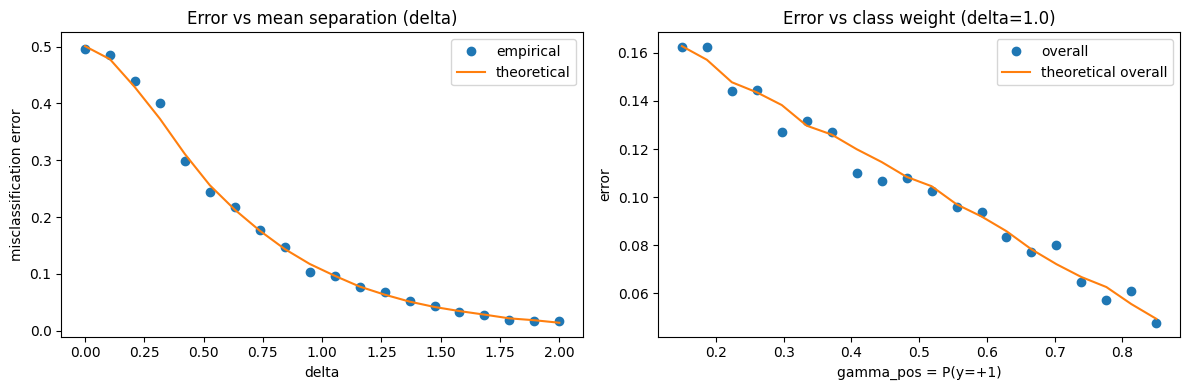

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(delta_grid, err_vs_delta, marker="o", linestyle ='', label="empirical")
axes[0].plot(delta_grid, err_vs_delta_th, label="theoretical")
axes[0].set_title("Error vs mean separation (delta)")
axes[0].set_xlabel("delta")
axes[0].set_ylabel("misclassification error")
axes[0].legend()

axes[1].plot(gamma_grid, err_total, marker="o", linestyle ='', label="overall")
axes[1].plot(gamma_grid, error_th_total, label="theoretical overall")
# axes[1].plot(gamma_grid, err_neg, marker="o", linestyle ='', label="cond. error (class -1)")
# axes[1].plot(gamma_grid, error_th_neg, label="theoretical error (class -1)")
# axes[1].plot(gamma_grid, err_pos, marker="o", linestyle ='', label="cond. error (class +1)")
# axes[1].plot(gamma_grid, error_th_pos, label="theoretical error (class +1)")
axes[1].set_title(f"Error vs class weight (delta={delta_fixed})")
axes[1].set_xlabel("gamma_pos = P(y=+1)")
axes[1].set_ylabel("error")
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Teacher–student model: regularization vs (i) test error and (ii) alignment to the teacher

We now move to a **teacher/student** setup:

- Features: `x ~ N(0, I)`
- Teacher: `y = sign(xᵀ θ★ + σ ε)` with `θ★` fixed and `ε ~ N(0,1)`
- Student: regularized logistic regression.

We sweep the ridge parameter `λ` and plot:
- the **test misclassification error**,
- the **cosine alignment** `cos(θ̂, θ★)`.

This is a good “sanity sweep” for *fast* experiments: it often shows a clear optimum `λ`.


In [ ]:
p = 50
n_train = 350
num_trial = 30
n_test = 5000
sigma = 0.5

def cosine_similarity(a, b):
    a = np.asarray(a, dtype=float).reshape(-1)
    b = np.asarray(b, dtype=float).reshape(-1)
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

x_model = dm.GaussianModel(p=p, mu=np.zeros(p), C=np.eye(p))
theta_star = dm.unit(rng.standard_normal(p))

teacher = dm.TeacherStudentModel(
    x_model=x_model,
    theta_teacher=theta_star,
    y_model="sign",
    noise_std=sigma,
)

loss = lr.LogisticLoss()

lam_grid = np.logspace(-3, 1, 15)
test_err = []
test_err_th = []
align = []
for lam in lam_grid:
    reg = lr.QuadraticRegularizer(a=np.zeros(p), H=float(lam) * np.eye(p))
    trainer = et.ERMTrainer(model=teacher, loss=loss, regularizer=reg)
    cossim = 0
    thetas = []
    for trial in range(num_trial):
        theta_hat, _, _ = trainer.sample_theta_hat(n=n_train, rng=rng, solver_maxiter=200)
        thetas.append(theta_hat)
        cossim+= cosine_similarity(theta_hat, theta_star)
    err = teacher.error_classif_emp(thetas, n_test=n_test, rng=rng)
    test_err.append(err)
    align.append(cossim/num_trial)
    solver = et.TheoryFixedPointSolver(model=teacher,loss=loss,regularizer=reg,n_train=n_train,mc_samples=10000,  # more samples for smaller etabdarng=np.random.default_rng(123),  # fixed for repeatability
        )
    th = solver.solve(max_iter=1000,tol= 1e-4,damping= 0.2,verbose=False,mu0=mu0,alpha0=alpha0,nu0=nu0,        )
    test_err_th.append(teacher.error_classif_th(th["mu"], th["alpha"], num_trials=100000))


# 3:21min

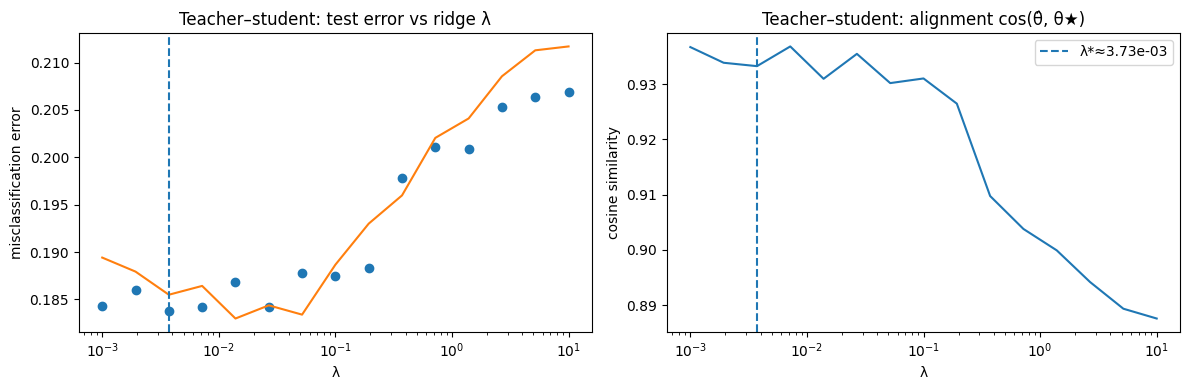

Best λ (min test error): 3.728e-03


In [22]:
lam_best = float(lam_grid[int(np.argmin(test_err))])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogx(lam_grid, test_err, marker="o", linestyle = '')
axes[0].semilogx(lam_grid, test_err_th)
axes[0].axvline(lam_best, linestyle="--")
axes[0].set_title("Teacher–student: test error vs ridge λ")
axes[0].set_xlabel("λ")
axes[0].set_ylabel("misclassification error")

axes[1].semilogx(lam_grid, align)
axes[1].axvline(lam_best, linestyle="--", label=f"λ*≈{lam_best:.2e}")
axes[1].set_title("Teacher–student: alignment cos(θ̂, θ★)")
axes[1].set_xlabel("λ")
axes[1].set_ylabel("cosine similarity")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Best λ (min test error): {lam_best:.3e}")


### 4.1 TeacherStudentModel inherits *classes* from the x-model

Even if `y_model='sign'` (binary labels), the **teacher's `num_classes`** is:

- `1` if `x_model` is a one-class feature model,
- `K` if `x_model` is a `BaseDataModel` with `K` classes (e.g. a `MultiClassModel`).

This matters for theory code and for class-conditional sampling.


In [23]:
# One-class x_model => teacher.num_classes = 1
print("teacher.num_classes (Gaussian x_model):", teacher.num_classes)

# Two-class x_model => teacher.num_classes = 2 (even though labels are still ±1)
x_mix = dm.MultiClassModel(
    components=[
        dm.GaussianModel(p=p, mu=-0.5 * np.eye(p)[0], C=np.eye(p)),
        dm.GaussianModel(p=p, mu=+0.5 * np.eye(p)[0], C=np.eye(p)),
    ],
    gamma=[0.6, 0.4],
    y_values=[0.0, 1.0],  # class labels (not used by the teacher)
)

teacher_mix = dm.TeacherStudentModel(
    x_model=x_mix,
    theta_teacher=theta_star,
    y_model="sign",
    noise_std=sigma,
)

print("teacher_mix.num_classes (MultiClass x_model):", teacher_mix.num_classes)

X0, y0 = teacher_mix.sample_class(0, 3, rng=rng)
X1, y1 = teacher_mix.sample_class(1, 3, rng=rng)
print("sample_class(0) mean first coord:", X0[:, 0].mean(), "labels:", y0[:3])
print("sample_class(1) mean first coord:", X1[:, 0].mean(), "labels:", y1[:3])


teacher.num_classes (Gaussian x_model): 1
teacher_mix.num_classes (MultiClass x_model): 2
sample_class(0) mean first coord: 0.550898752125662 labels: [-1.  1.  1.]
sample_class(1) mean first coord: 1.6033168008229646 labels: [ 1.  1. -1.]


## 5. MNIST-style demo: 8×8 downsampling + random features

This repo includes `MNISTGroupedDataModel`, which expects a local `.npz` file with arrays:
- `x_train`, `y_train`, `x_test`, `y_test` (or capitalization variants).

To keep this notebook **offline** and self-contained, we will:
1. Load scikit-learn’s `digits` dataset (8×8),
2. Embed each 8×8 image into a 28×28 canvas (MNIST-like format),
3. Save a local `mnist_like.npz`,
4. Use `MNISTGroupedDataModel` as usual.

Then we will:
- reduce one image to **8×8** using `create_downsampling_matrix`,
- train **random feature** classifiers and plot accuracy vs feature dimension `p`.


In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

def embed_8x8_to_28x28(img8):
    """Upscale 8×8 -> 24×24 by Kronecker, then pad to 28×28."""
    img8 = np.asarray(img8, dtype=float)
    img8 = img8 / 16.0  # digits dataset is 0..16
    img24 = np.kron(img8, np.ones((3, 3)))  # 24×24
    img28 = np.pad(img24, ((2, 2), (2, 2)), mode="constant")  # 28×28
    return (255.0 * img28).astype(np.uint8)

# Create a local MNIST-like .npz if needed
data_path = ROOT / "mnist_like_digits_28x28.npz"
if not data_path.exists():
    digits = load_digits()
    X = digits.images
    y = digits.target.astype(int)

    X28 = np.stack([embed_8x8_to_28x28(im) for im in X], axis=0)
    X_train, X_test, y_train, y_test = train_test_split(
        X28, y, test_size=0.33, random_state=0, stratify=y
    )
    np.savez_compressed(
        data_path,
        x_train=X_train,
        y_train=y_train,
        x_test=X_test,
        y_test=y_test,
    )
    print(f"Wrote {data_path} with shapes:", X_train.shape, X_test.shape)
else:
    print(f"Found existing {data_path}")


Found existing /workspaces/Empirical-risk-minimization-asymptotics/mnist_like_digits_28x28.npz


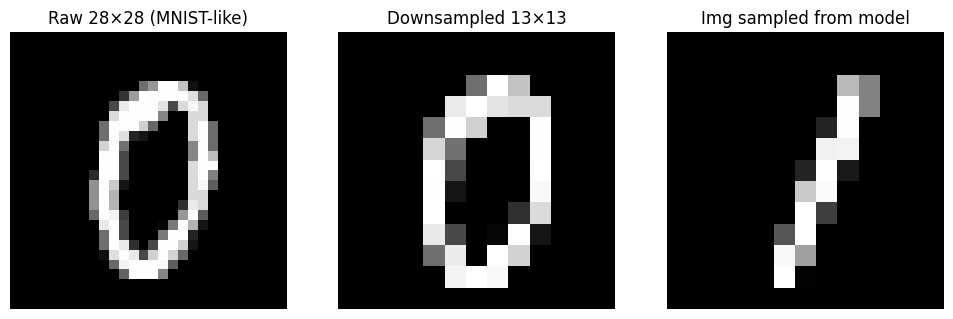

In [27]:
classes = [1, 0]
K = 2   # Number of classes (class 0 and class 1)

# Proportions for each class (uniform)
# gamma = [0.4, 0.6]
target_m = 13
W8 = dm.create_downsampling_matrix(target_m=target_m, original_dim=28)
p = target_m**2  # Dimensionality of features

# Instantiate the MixtureClassificationModel
model = dm.MNISTGroupedDataModel(
    data_path="./mnist.npz",
    split="train",
    stats_split="test",
    class_groups=[[1], [8]],
    W=W8,  # identity => raw pixels
    activation="identity",
    pixel_scaling="unit_interval",
    replace=False,
)

covs = model.class_params()['covs']
mus = model.class_params()['mus']
gamma = model.class_params()['gamma']

Mnist_raw = dm.MNISTGroupedDataModel(
    data_path="./mnist.npz",
    split="train",
    stats_split="test",
    class_groups=[[0]],
    W=None,  # identity => raw pixels
    activation="identity",
    pixel_scaling="unit_interval",
    replace=False,
)
rng = np.random.default_rng(123)
X0, y0 = Mnist_raw.sample_class(0, 1, rng=rng)
Xtst, ytst = model.sample_class(0, 1, rng=rng)
img28 = X0[0].reshape(28, 28)
img8 = (X0[0] @ W8.T).reshape(target_m, target_m)
img_sampled = Xtst.reshape(target_m, target_m)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
axes[0].imshow(img28, cmap="gray")
axes[0].set_title("Raw 28×28 (MNIST-like)")
axes[0].axis("off")

axes[1].imshow(img8, cmap="gray")
axes[1].set_title(f"Downsampled {target_m}×{target_m}")
axes[1].axis("off")

axes[2].imshow(img_sampled, cmap="gray")
axes[2].set_title("Img sampled from model")
axes[2].axis("off")

plt.tight_layout()
plt.show()


In [29]:
# --- Small wrapper: map class labels (e.g. 0/1) to values compatible with binary losses (±1). ---
class LabelMappingModel(dm.BaseDataModel):
    def __init__(self, base_model: dm.BaseDataModel, mapping: dict):
        self.base = base_model
        self.mapping = dict(mapping)
        self.p = int(base_model.p)

    @property
    def num_classes(self) -> int:
        return int(self.base.num_classes)

    def _map(self, y):
        y = np.asarray(y)
        # Works for scalar labels; if you feed super-labels u=(eps,y) this wrapper is NOT appropriate.
        y_out = np.vectorize(self.mapping.get)(y.astype(int))
        return y_out.astype(float)

    def sample(self, n: int, rng=None):
        X, y = self.base.sample(n, rng=rng)
        return X, self._map(y)

    def sample_class(self, class_index: int, n: int, rng=None):
        X, y = self.base.sample_class(class_index, n, rng=rng)
        return X, self._map(y)

    def class_params(self) -> dict:
        params = self.base.class_params()
        y_values = params.get("y_values")
        if y_values is None:
            y_values = list(range(self.num_classes))
        params["y_values"] = [float(self.mapping.get(int(v), v)) for v in y_values]
        return params

def train_and_score_mnist_rf(
    m: int,
    activation: str,
    lam: float = 1e-1,
    n_train: int = 400,
    n_test: int = 400,
):
    # Random features W: N(0,1/p_raw) so that Z has O(1) variance
    p_raw = 28 * 28
    W = rng.standard_normal((m, p_raw)) / np.sqrt(p_raw)

    train_base = dm.MNISTGroupedDataModel(
        data_path=str(data_path),
        split="train",
        stats_split="test",
        class_groups=class_groups,
        W=W,
        activation=activation,
        pixel_scaling="unit_interval",
        replace=False,
    )
    test_base = dm.MNISTGroupedDataModel(
        data_path=str(data_path),
        split="test",
        stats_split="test",
        class_groups=class_groups,
        W=W,
        activation=activation,
        pixel_scaling="unit_interval",
        replace=False,
    )

    # Map y in {0,1} -> {-1,+1}
    mapping = {0: -1.0, 1: +1.0}
    train_model = LabelMappingModel(train_base, mapping=mapping)
    test_model = LabelMappingModel(test_base, mapping=mapping)

    loss = lr.LogisticLoss()
    reg = lr.QuadraticRegularizer(a=np.zeros(m), H=float(lam) * np.eye(m))
    trainer = et.ERMTrainer(model=train_model, loss=loss, regularizer=reg)

    theta_hat, _, _ = trainer.sample_theta_hat(n=n_train, rng=rng, solver_maxiter=200)

    Xte, yte = test_model.sample(n_test, rng=rng)
    pred = dm.sign_pm1(Xte @ theta_hat)
    acc = float(np.mean(pred == yte))
    return acc

m_grid = [32, 64, 128, 256, 1024]
activations = ["identity", "relu"]

acc = {act: [] for act in activations}
for act in activations:
    for m in m_grid:
        acc[act].append(train_and_score_mnist_rf(m=m, activation=act, lam=1e-1))



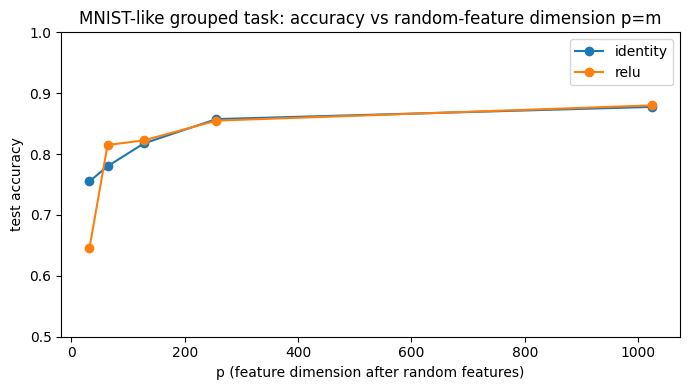

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
for act in activations:
    ax.plot(m_grid, acc[act], marker="o", label=act)

ax.set_title("MNIST-like grouped task: accuracy vs random-feature dimension p=m")
ax.set_xlabel("p (feature dimension after random features)")
ax.set_ylabel("test accuracy")
ax.set_ylim(0.5, 1.0)
ax.legend()
plt.tight_layout()
plt.show()
